# 4 Pre-Processing and Training Data<a id='4_Pre-Processing_and_Training_Data'></a>

## 4.1 Contents<a id='4.1_Contents'></a>
* [4 Pre-Processing and Training Data](#4_Pre-Processing_and_Training_Data)
  * [4.1 Contents](#4.1_Contents)
  * [4.2 Introduction](#4.2_Introduction)
  * [4.3 Imports](#4.3_Imports)
  * [4.4 Load Data](#4.4_Load_Data)
  * [4.5 Train/Test Split](#4.6_Train/Test_Split)
  * [4.6 Scale Dataset](#4.7_Scale_Dataset)
  * [4.7 Save Train Test Datasets](#4.13_Save_Train_Test_Datasets)
  * [4.8 Summary](#4.14_Summary)

## 4.2. Introduction<a id='4.2_Introduction'></a>

In the preceding notebooks, we performed exploratory data analysis and determined the features ('log_median_income','log_ev_adoption_lag','log_ev_charging_density','lag_missing_flag','log_ev_adoption_rate'(target)) for our overall dataset to be used for modeling. 

Key decisions from EDA phase include

1. 'ev_charging_density' requires log1p(x * 100) transformation to resolve heavy right skew and decimal-space log trap
2. All remaining core features except 'lag_missing_flag' were log-transformed along with target variable ev_adoption_rate to ensure a much more linear relationship.
3. Dropped features: 'income_per_vehicle', 'new_ev_purchase_ratio', 'bev_ratio_within_ev', 'cafv_eligibility_rate', 'ev_charging_stations', 'ev_growth_rate', 'population' (high VIF / weak correlation / anomalous outliers)


In this notebook we will create train/test sets and standardize our data. Next we will save the train/test sets for modeling in the next step.

We will create 2 model ready datasets for the modeling paths described below

1. Linear Regression : Identification & Quantification of EV Adoption Drivers.
2. KMeans Clustering : County Segmentation for Infrastructure Investment Prioritization.

County is not included as a feature for either dataset because for Linear Regression we would like to generalize coefficients across counties instead of memorizing high/low adoption counties. For KMeans, clustering would be based on geography instead of adoption behavior defeating the purpose of segmentation based on adoption behavior.

However, County and Year fields are kept throughout to interpret model results

##  4.3 Imports<a id='4.3_Imports'></a>

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
import datetime
from library.sb_utils import save_file

## 4.4 Load Data<a id='4.4_Load_Data'></a>

In [2]:
ev_data = pd.read_csv('../data/processed/ev_model_ready_data.csv')
ev_data.head()

,year,county,lag_missing_flag,log_median_income,log_ev_charging_density,log_ev_adoption_lag,log_ev_adoption_rate
0,2017,Adams,1,10.796510,0.404335,0.000000,0.037290
1,2018,Adams,0,10.875610,0.402159,0.037290,0.028692
2,2019,Adams,0,10.888110,0.684876,0.028692,0.050747
3,2020,Adams,0,10.940614,0.678166,0.050747,0.070323
4,2021,Adams,0,10.957904,0.671381,0.070323,0.115398


In [3]:
#ensure there is no missing data
ev_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     351 non-null    int64  
 1   county                   351 non-null    object 
 2   lag_missing_flag         351 non-null    int64  
 3   log_median_income        351 non-null    float64
 4   log_ev_charging_density  351 non-null    float64
 5   log_ev_adoption_lag      351 non-null    float64
 6   log_ev_adoption_rate     351 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 19.3+ KB


In [4]:
ev_data.describe()

,year,lag_missing_flag,log_median_income,log_ev_charging_density,log_ev_adoption_lag,log_ev_adoption_rate
count,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000
mean,2021.000000,0.111111,11.120280,0.801587,0.408391,0.524032
std,2.585675,0.314718,0.219315,0.547975,0.398531,0.440940
min,2017.000000,0.000000,10.650484,0.000000,0.000000,0.000000
25%,2019.000000,0.000000,10.964029,0.374780,0.100896,0.171562
50%,2021.000000,0.000000,11.096561,0.721588,0.286032,0.409108
75%,2023.000000,0.000000,11.264336,1.189924,0.603919,0.766586
max,2025.000000,1.000000,11.745029,2.511285,2.006578,2.149930


In [5]:
ev_data.isna().sum()

year                       0
county                     0
lag_missing_flag           0
log_median_income          0
log_ev_charging_density    0
log_ev_adoption_lag        0
log_ev_adoption_rate       0
dtype: int64

In [6]:
ev_data.duplicated().sum()

np.int64(0)

Now that we have ensured our dataset is model ready without any nulls, duplicates or data format issues, lets go ahead and create the train/test sets.

## 4.5 Train/Test Split<a id='4.5_Train/Test_Split'></a>

Our data is partitioned on county/year and hence we will have to do a time based split for the train and test sets. We are also going to model for 2 feature set/target variable variations as shown below.

In [7]:
#Feature Sets for 2 modeling approaches
target = 'log_ev_adoption_rate'
lr_features = ['log_median_income','log_ev_adoption_lag','log_ev_charging_density','lag_missing_flag'] #Linear Regression Features
km_features = ['log_median_income','log_ev_charging_density'] #KMeans Features
data = ev_data.copy()
data = data.sort_values(['county','year'])

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     351 non-null    int64  
 1   county                   351 non-null    object 
 2   lag_missing_flag         351 non-null    int64  
 3   log_median_income        351 non-null    float64
 4   log_ev_charging_density  351 non-null    float64
 5   log_ev_adoption_lag      351 non-null    float64
 6   log_ev_adoption_rate     351 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 19.3+ KB


Please Note : There will be no train/test split for KMeans since clustering is unsupervised. `ev_adoption_rate` will be attached as a label column so we can interpret which clusters correspond to high vs. low adoption after fitting.

In [9]:
#Create train test sets
#Linear Regression Set
train = data[data['year']<=2023].copy()
test = data[data['year']>2023].copy()
X_train_lr = train[lr_features]
y_train_lr = train[target]
X_test_lr = test[lr_features]
y_test_lr = test[target]
#KMeans Set - No train/test split for unsupervised learning set
X_km = data[km_features]
y_km = data[target]

In [10]:
X_train_lr.shape, X_test_lr.shape

((273, 4), (78, 4))

We went for an ~80/20 split for Train/Test data so we could get a decent test size for predictions.

In [11]:
y_train_lr.shape, y_test_lr.shape

((273,), (78,))

In [12]:
X_km.shape

(351, 2)

In [13]:
#Check the 'dtypes' attribute of 'X_train' and 'X_test to verify all features are numeric (Linear Regression)
X_train_lr.dtypes
X_test_lr.dtypes

log_median_income          float64
log_ev_adoption_lag        float64
log_ev_charging_density    float64
lag_missing_flag             int64
dtype: object

In [14]:
#Check the 'dtypes' attribute of 'X_train' and 'X_test to verify all features are numeric (KMeans)
X_km.dtypes

log_median_income          float64
log_ev_charging_density    float64
dtype: object

## 4.6 Scale Dataset<a id='4.6_Scale_Dataset'></a>

In [15]:
scaler = StandardScaler()
#Linear Regression Scaled Datasets
X_train_lr_scaled=pd.DataFrame(scaler.fit_transform(X_train_lr), columns = lr_features, index=X_train_lr.index)
X_test_lr_scaled=pd.DataFrame(scaler.transform(X_test_lr), columns = lr_features, index=X_test_lr.index)
#KMeans Scaled Dataset
X_km_scaled=pd.DataFrame(scaler.fit_transform(X_km), columns = km_features, index=X_km.index) 

Let's run some quick checks for both Linear Regression & KMeans scaled datasets.

In [16]:
#Linear Regression
print("Scaler fit on training data only. Applied to both train and test.")
print(f"\nTraining feature means (should be ~0):")
print(X_train_lr_scaled.mean().round(6))
print(f"\nTraining feature std devs (should be ~1):")
print(X_train_lr_scaled.std().round(6))

Scaler fit on training data only. Applied to both train and test.

Training feature means (should be ~0):
log_median_income         -0.0
log_ev_adoption_lag       -0.0
log_ev_charging_density   -0.0
lag_missing_flag           0.0
dtype: float64

Training feature std devs (should be ~1):
log_median_income          1.001837
log_ev_adoption_lag        1.001837
log_ev_charging_density    1.001837
lag_missing_flag           1.001837
dtype: float64


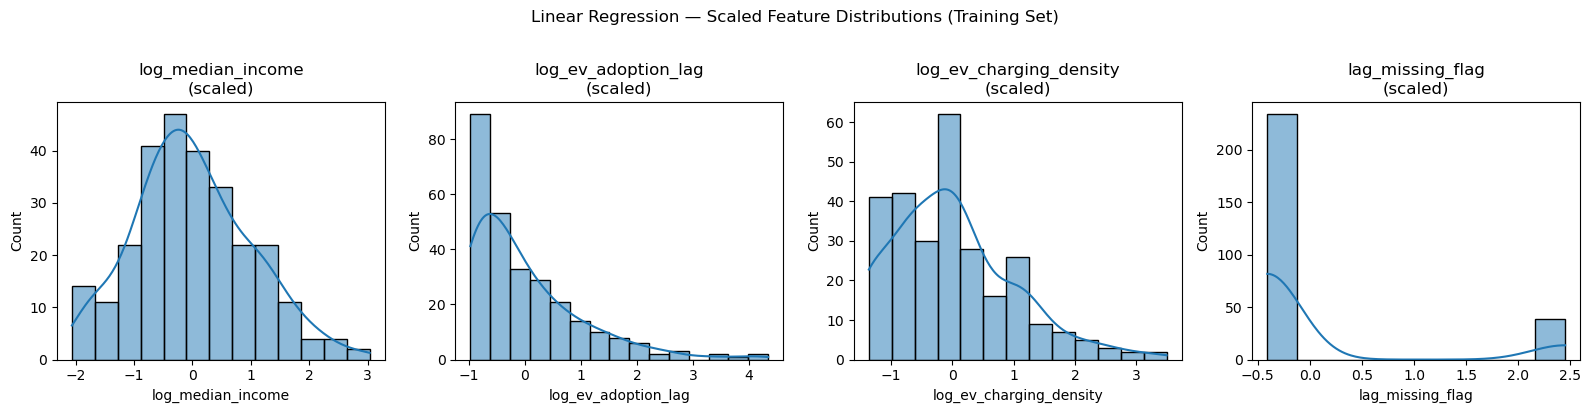

In [17]:
# Visualize scaled distributions — training set
fig, axes = plt.subplots(1, len(lr_features), figsize=(16, 4))
for i, col in enumerate(lr_features):
    sns.histplot(X_train_lr_scaled[col], ax=axes[i], kde=True)
    axes[i].set_title(f'{col}\n(scaled)')
plt.suptitle('Linear Regression — Scaled Feature Distributions (Training Set)', y=1.02)
plt.tight_layout()
plt.show()

In [18]:
#KMeans
print("Scaler fit on full dataset (no train/test split for unsupervised learning).")
print(f"\nFeature means (should be ~0):")
print(X_km_scaled.mean().round(6))
print(f"\nFeature std devs (should be ~1):")
print(X_km_scaled.std().round(6))

Scaler fit on full dataset (no train/test split for unsupervised learning).

Feature means (should be ~0):
log_median_income         -0.0
log_ev_charging_density   -0.0
dtype: float64

Feature std devs (should be ~1):
log_median_income          1.001428
log_ev_charging_density    1.001428
dtype: float64


## 4.7 Save best model object from pipeline<a id='4.7_Save_best_model_object_from_pipeline'></a>

Lets save the datasets.
1. Scaled Train and Test sets for Linear Regression.
2. Scaled dataset for KMeans Clustering.

All datasets contain county and year as the reference variables.

In [22]:
#Create train/test datasets to csv files for modeling in next step
datapath = '../data/processed'
#Reference Variables Dataset
ref = data[['county','year']]
#Create Train Test datasets for Linear Regression
lr_train_df = ref.loc[X_train_lr.index].copy().join(X_train_lr_scaled)
lr_train_df[target]=y_train_lr
lr_test_df = ref.loc[X_test_lr.index].copy().join(X_test_lr_scaled)
lr_test_df[target]=y_test_lr
#Create scaled dataset for KMeans
km_df = ref.copy().join(X_km_scaled)
km_df[target]=y_km #Label only

In [ ]:
Below are some quick sanity checks prior to saving the datasets.

In [46]:
print(f'lr_train_df rows & Column Count : {lr_train_df.shape}')
print(f'lr_train_df null values count : \n{lr_train_df.isna().sum()}')
print(f'lr_train_df duplicate records count : {lr_train_df.duplicated().sum()}')

lr_train_df rows & Column Count : (273, 7)
lr_train_df null values count : 
county                     0
year                       0
log_median_income          0
log_ev_adoption_lag        0
log_ev_charging_density    0
lag_missing_flag           0
log_ev_adoption_rate       0
dtype: int64
lr_train_df duplicate records count : 0


In [47]:
print(f'lr_test_df rows & Column Count : {lr_test_df.shape}')
print(f'lr_test_df null values count : \n{lr_test_df.isna().sum()}')
print(f'lr_test_df duplicate records count : {lr_test_df.duplicated().sum()}')

lr_test_df rows & Column Count : (78, 7)
lr_test_df null values count : 
county                     0
year                       0
log_median_income          0
log_ev_adoption_lag        0
log_ev_charging_density    0
lag_missing_flag           0
log_ev_adoption_rate       0
dtype: int64
lr_test_df duplicate records count : 0


In [48]:
print(f'km_df rows & Column Count : {km_df.shape}')
print(f'km_df null values count : \n{km_df.isna().sum()}')
print(f'km_df duplicate records count : {km_df.duplicated().sum()}')

km_df rows & Column Count : (351, 5)
km_df null values count : 
county                     0
year                       0
log_median_income          0
log_ev_charging_density    0
log_ev_adoption_rate       0
dtype: int64
km_df duplicate records count : 0


In [49]:
save_file(lr_train_df, 'ev_lr_train_scaled.csv', datapath)
save_file(lr_test_df, 'ev_lr_test_scaled.csv', datapath)
save_file(km_df, 'ev_km_scaled.csv', datapath)

Writing file.  "../data/processed\ev_lr_train_scaled.csv"
Writing file.  "../data/processed\ev_lr_test_scaled.csv"
Writing file.  "../data/processed\ev_km_scaled.csv"


## 4.8 Summary<a id='4.8_Summary'></a>

1. We started by loading the model ready dataset with log features created during Exploratory Data Analysis step. 

2. We checked for missing values for all features and target variable and made sure the dataset looked complete.

4. Train/Test sets were created for 2 different modeling strategies to capture different perspectives.

* For the first Linear Regression train/test split, log_ev_adoption_rate was our target and primary features were log_median_income, log_ev_charging_density, log_ev_adoption_lag & lag_missing_flag.

* For the second KMeans unsupervised learning dataset, no train/test split was needed. log_ev_adoption_rate was our target and log_median_income, log_ev_charging_density were our primary features.

5. Train/Test split was done in a time-aware manner since our dataset is a time series (county/year level data from 2017-2025).

6. Numerical Features were standardized to ensure model readiness.

7. Finally, Linear Regression train, test datasets and KMeans dataset with county & year as reference variables were saved for modeling in our next step.